# Latihan Mandiri (Tugas Praktikum #2)

 Nama: Muhammad Rizqy
 
 NIM: 2411513019
 
 Kelas: A


 # 1. Bank Account Race Condition

Bank Account Race Condition: Buat simulasi rekening bank sederhana dengan saldo awal 1.000.000. Buat 10 thread yang masing-masing
melakukan 10.000 kali operasi "tarik 1 lalu setor 1" (saldo -= 1; saldo += 1) tanpa lock. Jalankan dan amati apakah saldo akhir tetap
1.000.000. Ulangi dengan menambahkan threading.Lock() yang tepat, lalu bandingkan hasilnya dan jelaskan.

**Jawaban**

Percobaan dilakukan tanpa menggunakan lock untuk melihat apakah terjadi race condition.

In [5]:
import threading
import time

saldo = 1_000_000

def transaksi():
    global saldo
    
    for _ in range(10_000):
        saldo -= 1
        time.sleep(0)
        saldo += 1

threads = []

for i in range(10):
    t = threading.Thread(target=transaksi)
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("Saldo awal :", 1_000_000)
print("Saldo akhir:", saldo)

Saldo awal : 1000000
Saldo akhir: 1000000


### Hasil

Saldo akhir dapat berbeda dari Rp1.000.000 karena terjadi race condition saat beberapa thread mengakses saldo secara bersamaan.

### Percobaan dengan Lock

Selanjutnya digunakan `threading.Lock()` untuk mencegah race condition.

In [9]:
import threading
import time

saldo = 1_000_000
lock = threading.Lock()

def transaksi():
    global saldo
    
    for _ in range(10_000):
        with lock:
            saldo -= 1
            time.sleep(0)
            saldo += 1

threads = []

for i in range(10):
    t = threading.Thread(target=transaksi)
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("Saldo awal :", 1_000_000)
print("Saldo akhir:", saldo)

Saldo awal : 1000000
Saldo akhir: 1000000


### Kesimpulan

Dengan menggunakan `Lock`, saldo akhir tetap Rp1.000.000 karena akses ke saldo dilakukan secara bergantian sehingga race condition dapat dicegah.

# 2  Producer-Consumer dengan Banyak Consumer
Modifikasi contoh queue.Queue pada bagian 3 agar memiliki 1 producer dan 3 consumer yang
berjalan bersamaan. Pastikan seluruh consumer berhenti dengan baik ketika producer selesai (hint: perhatikan cara sinyal None diteruskan pada
contoh di atas, kalian perlu menyesuaikannya untuk 3 consumer).

**JAWABAN**

Pada program ini digunakan `queue.Queue()` sebagai tempat penyimpanan data antara producer dan consumer. Producer menghasilkan 10 data dan memasukkannya ke dalam queue. Terdapat 3 consumer yang mengambil dan memproses data secara bersamaan. Karena terdapat 3 consumer, maka diberikan **3 buah `None`** sebagai tanda bahwa producer sudah selesai menghasilkan data. Setiap consumer akan menerima satu `None`, kemudian berhenti.

In [10]:
import threading
import queue
import time

q = queue.Queue()


# Producer
def producer():
    for i in range(10):
        data = f"Data-{i+1}"
        q.put(data)

        print(f"Producer menghasilkan: {data}")
        time.sleep(0.1)

    # Karena ada 3 consumer,
    # maka diperlukan 3 None
    for _ in range(3):
        q.put(None)

    print("Producer selesai.")


# Consumer
def consumer(nama):
    while True:
        data = q.get()

        if data is None:
            print(f"{nama} berhenti.")
            q.task_done()
            break

        print(f"{nama} memproses {data}")
        time.sleep(0.2)

        q.task_done()


# Membuat 3 consumer
consumers = []

for i in range(3):
    t = threading.Thread(
        target=consumer,
        args=(f"Consumer-{i+1}",)
    )

    consumers.append(t)
    t.start()


# Membuat 1 producer
producer_thread = threading.Thread(target=producer)
producer_thread.start()


# Menunggu producer selesai
producer_thread.join()

# Menunggu semua data selesai diproses
q.join()

# Menunggu semua consumer berhenti
for t in consumers:
    t.join()


print("Semua proses selesai.")

Producer menghasilkan: Data-1
Consumer-1 memproses Data-1
Producer menghasilkan: Data-2
Consumer-2 memproses Data-2
Producer menghasilkan: Data-3
Consumer-1 memproses Data-3
Producer menghasilkan: Data-4Consumer-3 memproses Data-4

Producer menghasilkan: Data-5
Consumer-2 memproses Data-5
Producer menghasilkan: Data-6
Consumer-1 memproses Data-6
Producer menghasilkan: Data-7Consumer-3 memproses Data-7

Producer menghasilkan: Data-8
Consumer-2 memproses Data-8
Producer menghasilkan: Data-9
Consumer-1 memproses Data-9
Producer menghasilkan: Data-10Consumer-3 memproses Data-10

Producer selesai.
Consumer-2 berhenti.
Consumer-1 berhenti.
Consumer-3 berhenti.
Semua proses selesai.


### Penjelasan Soal 2

Program memiliki 1 producer dan 3 consumer.

Producer memasukkan 10 data ke dalam queue. Ketiga consumer kemudian mengambil
data dari queue dan memprosesnya.

Bagian yang paling penting adalah:

```python
for _ in range(3):
    q.put(None)



# 3  Eksperimen ThreadPoolExecutor
Ulangi eksperimen pada bagian 6 dengan jumlah file 50 (bukan 8) dan bandingkan max_workers = 2, 4, 8, dan
16. Plot waktu eksekusi vs max_workers. Apakah menambah max_workers terus-menerus selalu mempercepat proses? Jelaskan mengapa ada
titik jenuh.

**JAWABAN SOAL 3**

Pada percobaan ini dibuat 50 file dan setiap file akan diproses menggunakan
`ThreadPoolExecutor`.

Jumlah worker yang digunakan adalah 2, 4, 8, dan 16.

Tujuannya adalah membandingkan waktu eksekusi untuk melihat pengaruh jumlah
thread terhadap kecepatan proses.

In [11]:
import os

folder = "data_50_file"

# Membuat folder
os.makedirs(folder, exist_ok=True)

# Membuat 50 file
for i in range(50):
    nama_file = os.path.join(folder, f"file_{i+1}.txt")

    with open(nama_file, "w") as f:
        f.write("Data percobaan threading\n" * 100)

print("50 file berhasil dibuat.")

50 file berhasil dibuat.


In [16]:
import time
from concurrent.futures import ThreadPoolExecutor
import pandas as pd  # Memakai library pandas

# 1. Simulasi fungsi I/O
def baca_file(file_id):
    time.sleep(0.05)
    return 100

files = list(range(50))
workers_list = [2, 4, 8, 16]
data_hasil = []

# 2. Eksekusi eksperimen
for workers in workers_list:
    mulai = time.perf_counter()
    
    with ThreadPoolExecutor(max_workers=workers) as executor:
        hasil = list(executor.map(baca_file, files))
        
    selesai = time.perf_counter()
    waktu = selesai - mulai
    
    # Menyimpan hasil ke dalam list dictionary
    data_hasil.append({
        "Max Workers": workers,
        "Waktu Eksekusi (detik)": round(waktu, 4)
    })

# 3. Tampilkan sebagai Tabel Pandas
df = pd.DataFrame(data_hasil)
display(df)

,Max Workers,Waktu Eksekusi (detik)
0,2,1.2605
1,4,0.6562
2,8,0.3539
3,16,0.2041


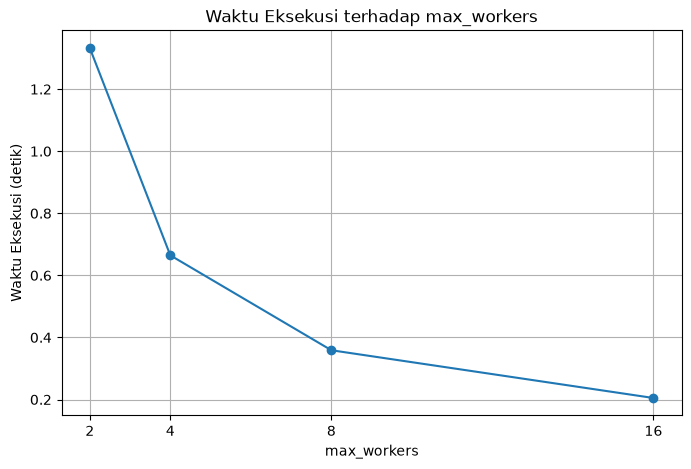

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    workers_list,
    waktu_eksekusi,
    marker="o"
)

plt.xlabel("max_workers")
plt.ylabel("Waktu Eksekusi (detik)")
plt.title("Waktu Eksekusi terhadap max_workers")

plt.xticks(workers_list)
plt.grid(True)

plt.show()

### Analisis Hasil

Berdasarkan hasil percobaan dan grafik, perubahan jumlah `max_workers`
mempengaruhi waktu eksekusi.

Penambahan worker dari 2 menjadi 4 atau 8 dapat membuat beberapa pekerjaan
berjalan secara bersamaan sehingga waktu eksekusi dapat berkurang.

Namun, menambah jumlah worker secara terus-menerus tidak selalu membuat
program semakin cepat.

Hal tersebut disebabkan oleh keterbatasan sumber daya komputer dan adanya
overhead untuk mengatur thread. Setelah jumlah worker sudah cukup, penambahan
worker berikutnya hanya memberikan peningkatan yang kecil atau bahkan dapat
membuat waktu eksekusi kembali meningkat.

Kondisi tersebut disebut sebagai **titik jenuh (saturation point)**.

Jadi, `max_workers` yang lebih besar tidak selalu berarti proses akan semakin
cepat.

#  4  Refleksi Singkat
berikan satu contoh kasus nyata (di luar contoh pada notebook ini) di mana threading Python akan membantu,
dan satu contoh kasus di mana threading Python tidak akan membantu dan sebaiknya menunggu materi multiprocessing (Pertemuan 3).

**JAWABAN SOAL 4  REFLEKSI**

### Contoh Threading Python Membantu

Threading Python membantu pada aplikasi yang melakukan banyak pekerjaan I/O,
misalnya program yang harus mengunduh banyak file dari internet. Saat satu
thread sedang menunggu respons dari server, thread lain dapat melakukan
pekerjaan lain. Dengan demikian, waktu tunggu dapat dimanfaatkan dan proses
dapat berjalan lebih efisien.

### Contoh Threading Python Tidak Membantu

Threading Python tidak terlalu membantu untuk pekerjaan CPU-bound, misalnya
melakukan perhitungan matematika yang sangat berat pada banyak data. Pada
CPython terdapat GIL (Global Interpreter Lock) yang membatasi eksekusi
bytecode Python oleh thread pada satu waktu. Akibatnya, penggunaan banyak
thread tidak selalu membuat pekerjaan CPU-bound menjadi lebih cepat. Untuk
kasus seperti ini, `multiprocessing` lebih sesuai karena pekerjaan dapat
dijalankan menggunakan beberapa proses.